# HSIC vs CKA

Raw HSIC is unbounded and its magnitude depends on sample size and kernel bandwidth.  **CKA** normalizes HSIC to [0, 1], making it interpretable and — with linear kernels — exactly scale-invariant. **Debiased CKA** further corrects finite-sample bias.

Side-by-side comparison of HSIC and CKA as dependence measures. HSIC is unbounded and its magnitude depends on sample size and kernel bandwidth. CKA normalizes HSIC to [0, 1], making it interpretable. With linear kernels, CKA is also exactly scale-invariant. Look for how the two metrics diverge as data dimensionality increases.

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np

import fairkl
from _style import SCATTER_KW, style_ax

## 1. Scale Invariance (Linear Kernels)

With **linear** kernels, $\text{HSIC}(cf, q) = c^2 \cdot \text{HSIC}(f, q)$ while CKA is exactly invariant: the $c^2$ cancels in the ratio.

With RBF kernels and fixed bandwidth, both metrics change when data is scaled (the kernel matrix itself changes).  The key advantage of CKA is **boundedness** [0, 1], not scale invariance per se.

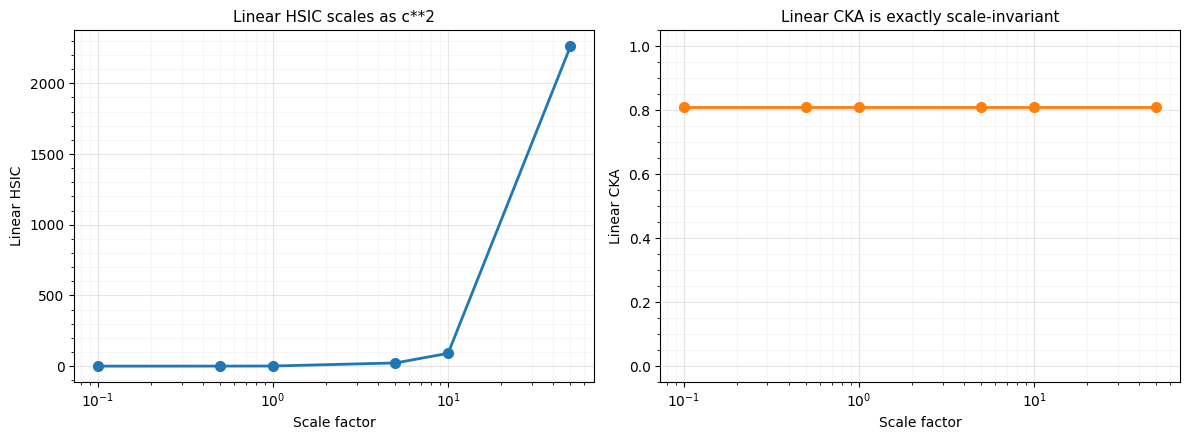

In [2]:
rng = np.random.default_rng(0)
n = 100
f = rng.standard_normal((n, 1)).astype("float32")
q = (f + 0.5 * rng.standard_normal((n, 1))).astype("float32")

scales = [0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
hsic_vals, cka_vals = [], []
for s in scales:
    fs = (f * s).astype("float32")
    hsic_vals.append(float(fairkl.hsic_linear(fs, q)))
    cka_vals.append(float(fairkl.cka_linear(fs, q)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(scales, hsic_vals, "o-", color="C0", lw=2, markersize=7)
axes[0].set_xlabel("Scale factor")
axes[0].set_ylabel("Linear HSIC")
axes[0].set_title("Linear HSIC scales as c**2", fontsize=11)
axes[0].set_xscale("log")
style_ax(axes[0])

axes[1].plot(scales, cka_vals, "o-", color="C1", lw=2, markersize=7)
axes[1].set_xlabel("Scale factor")
axes[1].set_ylabel("Linear CKA")
axes[1].set_title("Linear CKA is exactly scale-invariant", fontsize=11)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.05, 1.05)
style_ax(axes[1])

plt.tight_layout()
plt.show()

## 2. Interpretability

CKA is always in [0, 1].

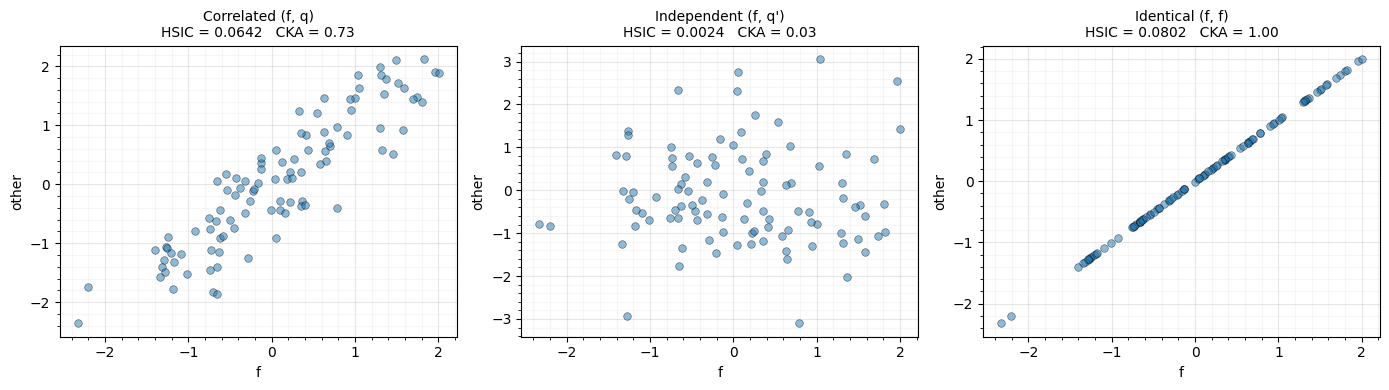

In [3]:
q_indep = rng.standard_normal((n, 1)).astype("float32")

pairs = {
    "Correlated (f, q)": (f, q),
    "Independent (f, q')": (f, q_indep),
    "Identical (f, f)": (f, f),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, (a, b)) in zip(axes, pairs.items()):
    hsic_val = float(fairkl.hsic_rbf(a, b))
    cka_val = float(fairkl.cka_rbf(a, b))
    ax.scatter(a.ravel(), b.ravel(), c="C0", **SCATTER_KW)
    ax.set_title(f"{label}\nHSIC = {hsic_val:.4f}   CKA = {cka_val:.2f}", fontsize=10)
    ax.set_xlabel("f")
    ax.set_ylabel("other")
    style_ax(ax)
plt.tight_layout()
plt.show()

## 3. Biased vs Debiased CKA

With random high-dimensional data, biased CKA inflates.

> **When does debiasing matter?** The bias in standard CKA grows when
> the feature dimension d is large relative to the sample size n. For
> small n and high d (e.g. n=50, d=500), biased CKA reports spurious
> dependence between independent random matrices. Debiased CKA
> (Nguyen et al. 2020) subtracts the expected bias term, keeping the
> estimate near zero for truly independent data.

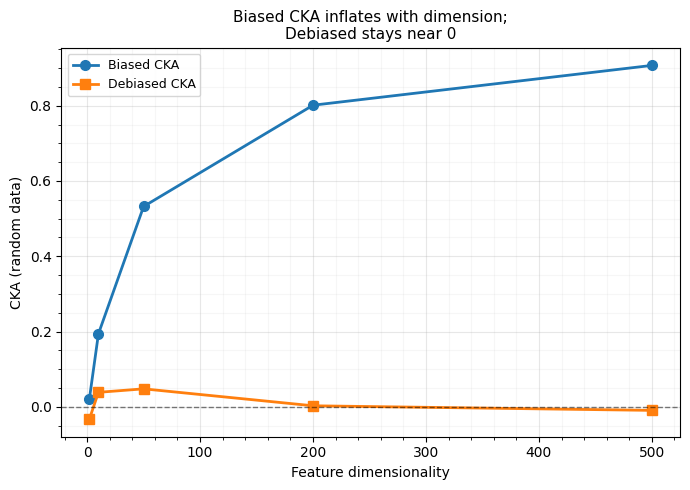

In [4]:
dims = [2, 10, 50, 200, 500]
biased_vals, debiased_vals = [], []

for d in dims:
    X = rng.standard_normal((50, d)).astype("float32")
    Y = rng.standard_normal((50, d)).astype("float32")
    biased_vals.append(float(fairkl.cka_linear(X, Y, debiased=False)))
    debiased_vals.append(float(fairkl.cka_linear(X, Y, debiased=True)))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(dims, biased_vals, "o-", color="C0", lw=2, label="Biased CKA", markersize=7)
ax.plot(dims, debiased_vals, "s-", color="C1", lw=2, label="Debiased CKA", markersize=7)
ax.axhline(0, color="k", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Feature dimensionality")
ax.set_ylabel("CKA (random data)")
ax.set_title("Biased CKA inflates with dimension;\nDebiased stays near 0", fontsize=11)
ax.legend(fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.show()

## 4. Linear vs RBF CKA

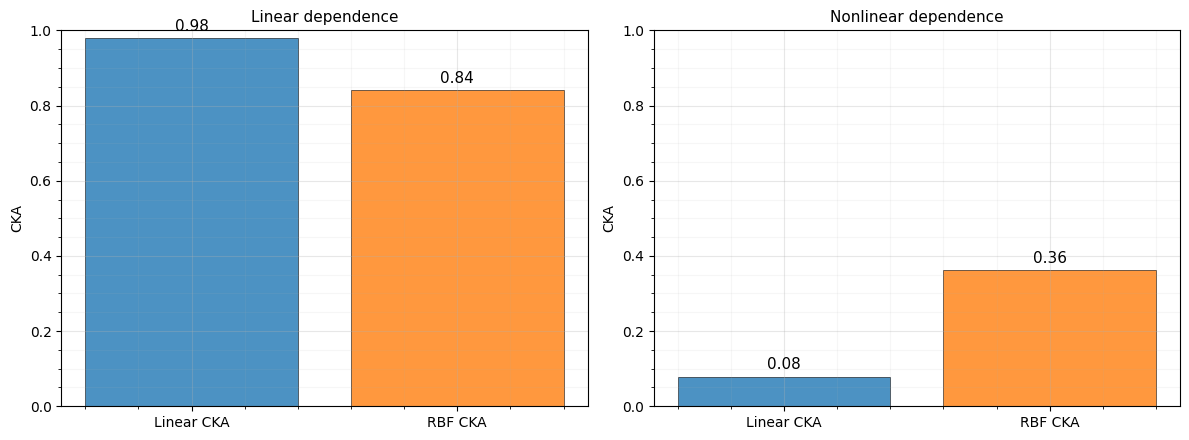

In [5]:
f_lin = rng.standard_normal((100, 1)).astype("float32")
q_lin = (2.0 * f_lin + 0.3 * rng.standard_normal((100, 1))).astype("float32")

f_nl = rng.standard_normal((100, 1)).astype("float32")
q_nl = (f_nl**2 + 0.3 * rng.standard_normal((100, 1))).astype("float32")

results = {
    "Linear dependence": {
        "linear": float(fairkl.cka_linear(f_lin, q_lin)),
        "rbf": float(fairkl.cka_rbf(f_lin, q_lin)),
    },
    "Nonlinear dependence": {
        "linear": float(fairkl.cka_linear(f_nl, q_nl)),
        "rbf": float(fairkl.cka_rbf(f_nl, q_nl)),
    },
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (label, vals) in zip(axes, results.items()):
    bars = ax.bar(
        ["Linear CKA", "RBF CKA"],
        [vals["linear"], vals["rbf"]],
        color=["C0", "C1"],
        edgecolor="k",
        linewidth=0.5,
        alpha=0.8,
    )
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("CKA")
    for bar, v in zip(bars, [vals["linear"], vals["rbf"]]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{v:.2f}",
            ha="center",
            fontsize=11,
        )
    style_ax(ax)
plt.tight_layout()
plt.show()